### Project objective : 
#### Analyze customer churn behavior in a telecom company to identify the characteristics of customers who are more likely to leave the service, discover patterns in customer demographics and services, and provide business insights that can help improve customer retention.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\WA_Fn-UseC_-Telco-Customer-Churn-selected-columns.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Data Validation

In [53]:
df.shape

(7043, 19)

In [54]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [55]:
df[df.isnull().any(axis = 1)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [56]:
pd.reset_option('display.max_rows')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [57]:
pd.set_option('display.max_columns' , None)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [58]:
df.dropna(how = 'all' , inplace = True)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [59]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [60]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,3875,4171,2365,11,5174


### Data Cleaning

In [61]:
df.columns = df.columns.str.title()
df

,Customerid,Gender,Seniorcitizen,Partner,Dependents,Tenure,Phoneservice,Multiplelines,Internetservice,Onlinesecurity,Onlinebackup,Deviceprotection,Techsupport,Contract,Paperlessbilling,Paymentmethod,Monthlycharges,Totalcharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [62]:
df.rename(columns={'Customerid': 'Customer_ID' , 'Phoneservice':'Phone_Service' , 'Multiplelines':'Multiple_lines' , 'Internetservice' :'Internet_service' , '	Onlinesecurity' : '	Online_security' , 'Onlinebackup' :'Online_backup' , 'Deviceprotection' :'Device_protection' , 'Techsupport'  :'Tech_support' ,'Paperlessbilling':'Paperless_billing' , 'Paymentmethod':'Payment_method', 'Monthlycharges' :'Monthly_charges' ,'Totalcharges' : 'Total_charges' , 'Onlinesecurity' : 'Online_security' , 'Seniorcitizen' : 'Senior_citizen' }, inplace=True)
df

,Customer_ID,Gender,Senior_citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_lines,Internet_service,Online_security,Online_backup,Device_protection,Tech_support,Contract,Paperless_billing,Payment_method,Monthly_charges,Total_charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [63]:
df['Lines_count'] = df['Multiple_lines']
df.loc[df['Multiple_lines'] == 'No phone service', 'Lines_count'] = 'Internet Only'
df.loc[df['Multiple_lines'] == 'No', 'Lines_count'] = 'Single_line'
df.loc[df['Multiple_lines'] == 'Yes', 'Lines_count'] = '2 or more lines'
## Another Way
# df['Lines_count'] = df['Multiple_lines'].map({'No phone service': 'Internet Only', 'No': 'Single_line', 'Yes': '2 or more lines'})
df

,Customer_ID,Gender,Senior_citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_lines,Internet_service,Online_security,Online_backup,Device_protection,Tech_support,Contract,Paperless_billing,Payment_method,Monthly_charges,Total_charges,Churn,Lines_count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Internet Only
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,No,Single_line
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Single_line
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No,Internet Only
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Single_line
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,2 or more lines
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.9,No,2 or more lines
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Internet Only
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,2 or more lines


### Data Analysis

In [64]:
df.max()

Customer_ID            9995-HOTOH
Gender                       Male
Senior_citizen                  1
Partner                       Yes
Dependents                    Yes
Tenure                         72
Phone_Service                 Yes
Multiple_lines                Yes
Internet_service               No
Online_security               Yes
Online_backup                 Yes
Device_protection             Yes
Tech_support                  Yes
Contract                 Two year
Paperless_billing             Yes
Payment_method       Mailed check
Monthly_charges            118.75
Total_charges               999.9
Churn                         Yes
Lines_count           Single_line
dtype: object

In [65]:
df['Gender'].count()

np.int64(7043)

In [66]:
df[df['Gender'] == 'Female']['Gender'].value_counts() 
# males = 3555 

Gender
Female    3488
Name: count, dtype: int64

In [67]:
Dep = df[['Dependents' , 'Tenure' , 'Monthly_charges' , 'Total_charges' , 'Contract' , 'Churn']]
Dep

,Dependents,Tenure,Monthly_charges,Total_charges,Contract,Churn
0,No,1,29.85,29.85,Month-to-month,No
1,No,34,56.95,1889.5,One year,No
2,No,2,53.85,108.15,Month-to-month,Yes
3,No,45,42.30,1840.75,One year,No
4,No,2,70.70,151.65,Month-to-month,Yes
...,...,...,...,...,...,...
7038,Yes,24,84.80,1990.5,One year,No
7039,Yes,72,103.20,7362.9,One year,No
7040,Yes,11,29.60,346.45,Month-to-month,No
7041,No,4,74.40,306.6,Month-to-month,Yes


In [68]:
Dep1 = Dep[Dep['Dependents'] == 'No'].value_counts().astype(int).to_frame()
Dep1
# Total count = 4806

count
Dependents Tenure Monthly_charges Total_charges Contract       Churn       
No         1      20.20           20.2          Month-to-month Yes        6
                  19.75           19.75         Month-to-month No         6
                  19.55           19.55         Month-to-month No         5
                  19.65           19.65         Month-to-month No         5
                  45.30           45.3          Month-to-month Yes        5
...                                                                     ...
           13     73.35           931.55        Month-to-month No         1
                  71.95           923.85        Month-to-month No         1
                  70.45           849.1         Month-to-month No         1
                  70.15           931.75        Month-to-month No         1
           72     118.20          8547.15       Two year       No         1

[4806 rows x 1 columns]

In [69]:
Dep2 = Dep[Dep['Dependents'] == 'Yes'].value_counts().astype(int).to_frame()
Dep2.sort_values(by = 'Monthly_charges' , ascending = False)
#Total count = 2103

count
Dependents Tenure Monthly_charges Total_charges Contract       Churn       
Yes        72     118.75          8672.45       Two year       No         1
                  117.60          8308.9        Two year       No         1
                  117.50          8670.1        Two year       No         1
                  116.85          8477.7        Two year       No         1
                  116.80          8456.75       Two year       No         1
...                                                                     ...
           4      18.85           84.2          Month-to-month No         1
           1      18.80           18.8          One year       No         1
           14     18.80           255.55        Two year       No         1
           13     18.80           251.25        Month-to-month No         1
           25     18.70           383.65        Two year       No         1

[2103 rows x 1 columns]

In [70]:
df['Customer_ID'].count()

np.int64(7043)

In [71]:
Ch_count = df['Churn'].value_counts()
Ch_count

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [72]:
#df.loc[df['Churn'] == 'No'].value_counts().count().astype(int) => Another way
len(df[df['Churn'] == 'No'])

5174

In [73]:
len(df[df['Churn'] == 'Yes'])

1869

In [76]:
int(df['Monthly_charges'].sum())
# Another way => df['Monthly_charges'.sum().astype(int)]

456116

In [77]:
invalid_values = df[pd.to_numeric(df['Total_charges'], errors='coerce').isnull()]['Total_charges'].unique()
invalid_values

array([' '], dtype=object)

In [78]:
df['Total_charges'] = pd.to_numeric(df['Total_charges'], errors='coerce')

In [79]:
int(df['Total_charges'].sum())

16056168

In [ ]:
## males = 3,555 
## Females = 3,488

In [157]:
pd.crosstab(df['Gender'] , df['Churn'])

Churn,No,Yes
Gender,,
Female,2549,939
Male,2625,930


In [80]:
len(df[(df['Churn'] == 'Yes') & (df['Gender'] == 'Female')])
# Male with churn => 1869 - 939 = 930 
# Male without churn => 2,625
# Female with churn => 939
# Female without churn => 2,549

939

In [118]:
df.groupby('Contract')['Monthly_charges'].mean().round(1).to_frame()

,Monthly_charges
Contract,
Month-to-month,66.4
One year,65.0
Two year,60.8


In [121]:
df.groupby('Contract')['Total_charges'].mean().round(1).to_frame().sort_values(by = 'Total_charges' , ascending = False)

,Total_charges
Contract,
Two year,3728.9
One year,3034.7
Month-to-month,1369.3


In [125]:
df.groupby('Internet_service')['Total_charges'].mean().round(1).to_frame().sort_values(by = 'Total_charges' , ascending = False)

,Total_charges
Internet_service,
Fiber optic,3205.3
DSL,2119.8
No,665.2


In [127]:
df.groupby('Payment_method')['Total_charges'].mean().round(1).to_frame().sort_values(by = 'Total_charges' , ascending = False)

,Total_charges
Payment_method,
Bank transfer (automatic),3079.3
Credit card (automatic),3071.4
Electronic check,2090.9
Mailed check,1054.5


In [131]:
df.groupby('Churn')['Monthly_charges'].mean().round(1).to_frame().sort_values(by = 'Monthly_charges' , ascending = False)

,Monthly_charges
Churn,
Yes,74.4
No,61.3


In [132]:
df.groupby('Churn')['Total_charges'].mean().round(1).to_frame().sort_values(by = 'Total_charges' , ascending = False)

,Total_charges
Churn,
No,2555.3
Yes,1531.8


In [82]:
df.corr(numeric_only= True)

,Senior_citizen,Tenure,Monthly_charges,Total_charges
Senior_citizen,1.000000,0.016567,0.220173,0.102411
Tenure,0.016567,1.000000,0.247900,0.825880
Monthly_charges,0.220173,0.247900,1.000000,0.651065
Total_charges,0.102411,0.825880,0.651065,1.000000


In [83]:
df.loc[(df['Tech_support'] == 'Yes') & (df['Churn'] == 'Yes')]
# 310 from 7043 => Tech_support related wiht Churn 
# 1734 with TECHNICAL Support and no churn

,Customer_ID,Gender,Senior_citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_lines,Internet_service,Online_security,Online_backup,Device_protection,Tech_support,Contract,Paperless_billing,Payment_method,Monthly_charges,Total_charges,Churn,Lines_count
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,2 or more lines
18,4190-MFLUW,Female,0,Yes,Yes,10,Yes,No,DSL,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,Single_line
104,3192-NQECA,Male,0,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.00,7611.85,Yes,2 or more lines
141,4080-OGPJL,Female,0,No,No,8,Yes,Yes,DSL,Yes,No,No,Yes,Month-to-month,No,Electronic check,71.15,563.65,Yes,2 or more lines
171,1875-QIVME,Female,0,Yes,No,2,Yes,Yes,Fiber optic,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.40,242.80,Yes,2 or more lines
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6972,6664-FPDAC,Female,1,No,No,56,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,One year,Yes,Electronic check,111.95,6418.90,Yes,2 or more lines
6986,3976-BWUCK,Female,0,Yes,No,30,Yes,Yes,Fiber optic,No,Yes,No,Yes,Month-to-month,Yes,Credit card (automatic),94.10,2804.45,Yes,2 or more lines
6996,4174-LPGTI,Female,0,Yes,Yes,41,Yes,No,DSL,No,Yes,No,Yes,One year,Yes,Bank transfer (automatic),66.50,2728.60,Yes,Single_line
7011,5482-NUPNA,Female,0,No,No,4,Yes,No,DSL,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,60.40,272.15,Yes,Single_line


In [84]:
pd.crosstab(df['Senior_citizen'] , df['Paperless_billing'])

Paperless_billing,No,Yes
Senior_citizen,,
0,2606,3295
1,266,876


In [85]:
df.loc[df['Internet_service'] == 'DSL' , 'Churn'].value_counts()

Churn
No     1962
Yes     459
Name: count, dtype: int64

In [86]:
df.loc[df['Internet_service'] == 'Fiber optic' , 'Churn'].value_counts()

Churn
No     1799
Yes    1297
Name: count, dtype: int64

In [87]:
Cont_c = pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(1) * 100
Cont_c

Churn,No,Yes
Contract,,
Month-to-month,60.0,40.0
One year,90.0,10.0
Two year,100.0,0.0


In [88]:
Internet_c = pd.crosstab(df['Internet_service'] , df['Churn'])
Internet_c

Churn,No,Yes
Internet_service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [89]:
L_c = pd.crosstab(df['Lines_count'] , df['Churn'])
L_c

Churn,No,Yes
Lines_count,,
2 or more lines,2121,850
Internet Only,512,170
Single_line,2541,849


In [90]:
Pay_c = pd.crosstab(df['Payment_method'] , df['Churn'])
Pay_c

Churn,No,Yes
Payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [91]:
(pd.crosstab(df['Payment_method'] , df['Churn'] , normalize= 'index')*100).round(1)

Churn,No,Yes
Payment_method,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


In [92]:
Dc = pd.crosstab(df['Dependents'] , df['Churn'])
Dc

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


In [93]:
pd.crosstab(df['Tech_support'] , df['Churn'])

Churn,No,Yes
Tech_support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [95]:
df.groupby(['Dependents', 'Total_charges'])['Total_charges'].count()

Dependents  Total_charges
No          18.85            2
            18.90            1
            19.05            1
            19.10            3
            19.15            1
                            ..
Yes         8476.50          1
            8477.70          1
            8543.25          1
            8670.10          1
            8672.45          1
Name: Total_charges, Length: 6680, dtype: int64

In [96]:
df.groupby('Dependents')['Monthly_charges'].mean().round(1)

Dependents
No     67.0
Yes    59.5
Name: Monthly_charges, dtype: float64

In [97]:
df.groupby('Dependents')['Total_charges'].mean().round(1)

Dependents
No     2187.7
Yes    2508.0
Name: Total_charges, dtype: float64

In [98]:
M_T =((df.groupby('Contract')[['Total_charges' , 'Monthly_charges']].sum() / df[['Total_charges' , 'Monthly_charges']].sum()) * 100).round(1)
M_T

,Total_charges,Monthly_charges
Contract,,
Month-to-month,33.0,56.4
One year,27.8,21.0
Two year,39.1,22.6


### Data Visualization

In [100]:
G_vis = df['Gender'].value_counts()
G_vis

Gender
Male      3555
Female    3488
Name: count, dtype: int64

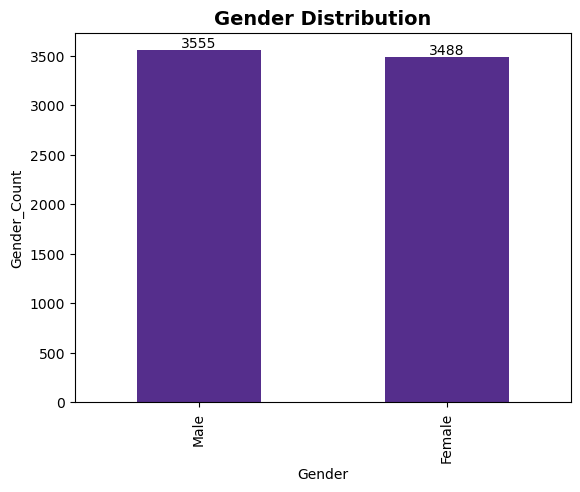

In [101]:
G_vis.plot(kind = 'bar' , color = '#552E8C' , xlabel = 'Gender' , ylabel = 'Gender_Count' )
plt.title('Gender Distribution' , fontsize = 14 , fontweight = 'bold')
for ind , vl in enumerate(G_vis):
    plt.text(ind, vl ,vl , ha = 'center' ,va = 'bottom' )


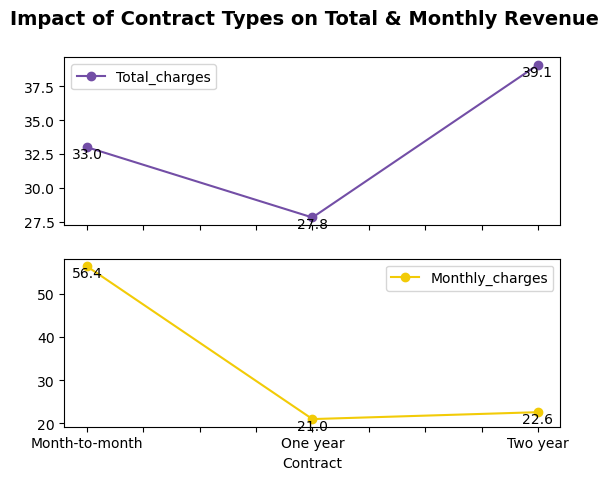

In [102]:
Graph = M_T.plot(subplots = True , color = ['#734EA6' , '#F2CB07'] , marker = 'o' )
plt.suptitle('Impact of Contract Types on Total & Monthly Revenue', fontsize=14, fontweight='bold')
for i, col_name in enumerate(M_T.columns):
    ax = Graph[i] 
    
    for ind, vl in enumerate(M_T[col_name]): #values
     
        ax.text(ind, vl, vl, ha='center', va='top', fontsize=10 )
       

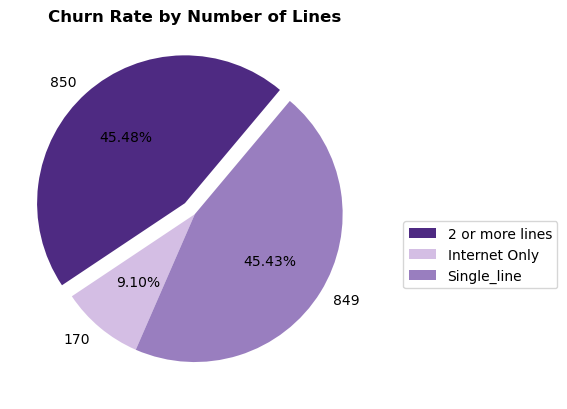

In [103]:
explode = [0.1 if value == L_c['Yes'] .max()
            else 0 
           for value in L_c['Yes']]
plt.pie( L_c['Yes'] , startangle= 50 , colors = ['#4E2A82', '#D4BEE4', '#997EBF'] , labels = L_c['Yes'], explode = explode , autopct='%1.2f%%') #,textprops={'fontweight': 'bold'}
plt.legend(labels = L_c.index , loc = 'upper right' , bbox_to_anchor=(1.5, 0.5) )
plt.title(label= 'Churn Rate by Number of Lines' , fontweight = 'bold')
plt.show()

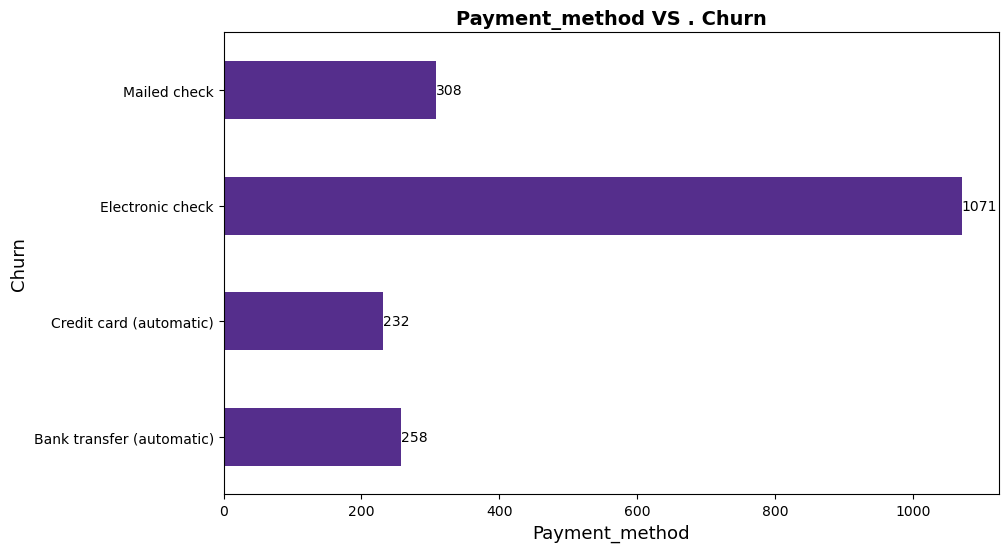

In [104]:
Pay_c['Yes'].plot(kind = 'barh' , color = '#552E8C' , figsize = (10 , 6) , title = 'Payment_method VS . Churn')
plt.title('Payment_method VS . Churn' , fontsize = 14 , fontweight = 'bold')
plt.xlabel('Payment_method', fontsize=13)
plt.ylabel('Churn', fontsize=13)
for ind ,vl in enumerate(Pay_c['Yes']):
    plt.text(vl ,ind , vl , ha = 'left' , va = 'center' , fontsize = 10 )

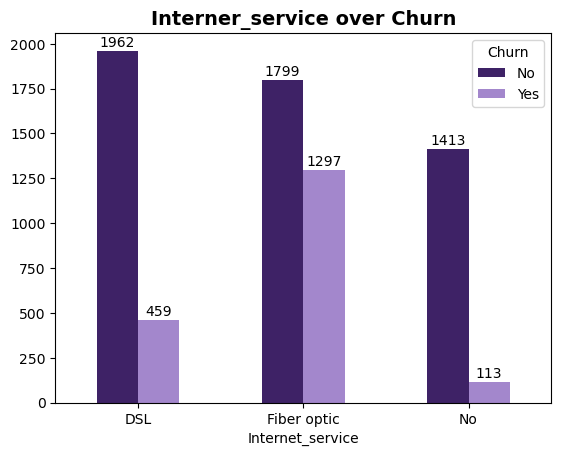

In [105]:
Graph_I = Internet_c.plot(kind='bar' , color =['#3E2266' , '#A387CC'] , rot = 0)
plt.title('Interner_service over Churn' , fontsize = 14 , fontweight = 'bold')
# for text like(yes , no) (un numeric)
for container in Graph_I.containers:
    Graph_I.bar_label(container, padding=1, fontsize=10)

Text(0, 0.5, 'Contract')

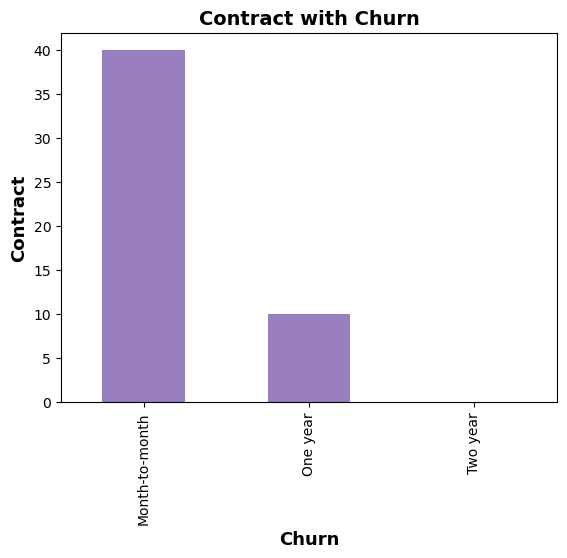

In [115]:
Cont_c['Yes'].plot(kind = 'bar' , color = '#997EBF')
plt.title('Contract with Churn' , fontsize = 14 , fontweight = 'bold') 
plt.xlabel('Churn' , fontsize = 13 , fontweight = 'bold')
plt.ylabel('Contract' , fontsize = 13 , fontweight = 'bold')

Text(0.5, 0, 'Churn_count')

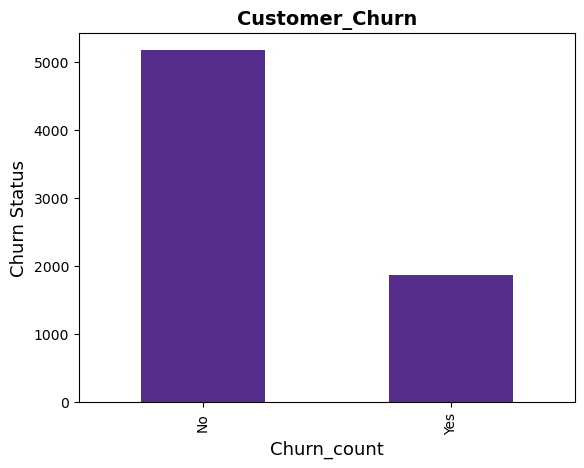

In [106]:
Ch_count.plot(kind = 'bar' , color = ['#552E8C'] )
plt.title('Customer_Churn', fontsize=14, fontweight='bold')
plt.ylabel('Churn Status', fontsize=13)
plt.xlabel('Churn_count', fontsize=13)


Text(0, 0.5, 'Occurrence')

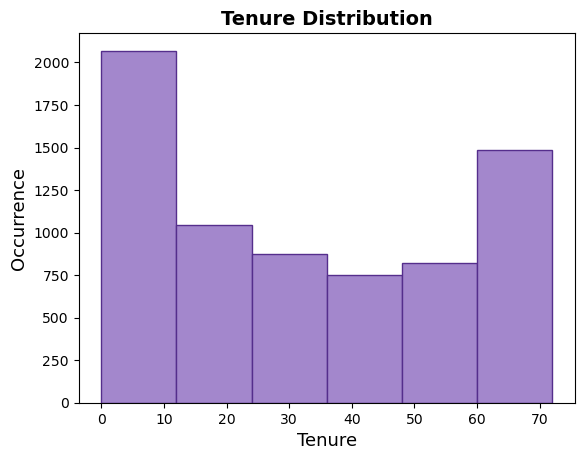

In [151]:
Tg = df['Tenure'].plot(kind='hist', bins=6 , color ='#A387CC'  , edgecolor='#552E8C' )
df['Tenure'].plot( kind='kde', color='#F2CB07', linewidth=2.5, secondary_y=True, ax=G1)
plt.title('Tenure Distribution' , fontsize = 14 , fontweight = 'bold')
plt.xlabel('Tenure', fontsize=13)
plt.ylabel('Occurrence', fontsize=13)


Text(0, 0.5, 'Frequency')

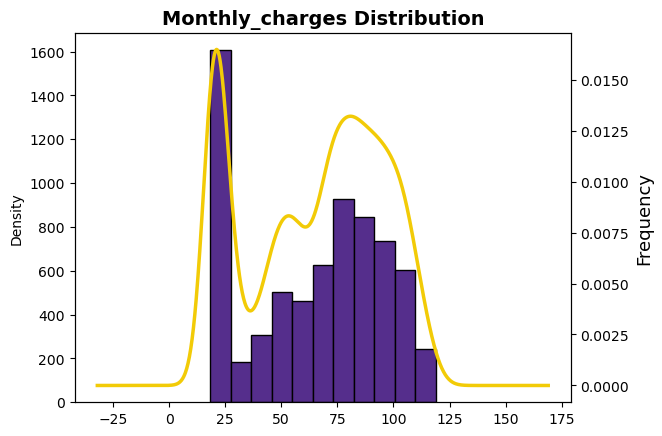

In [107]:
G1 = df['Monthly_charges'].plot(kind='hist', bins=11 , color ='#552E8C'  , edgecolor='black' )
df['Monthly_charges'].plot( kind='kde', color='#F2CB07', linewidth=2.5, secondary_y=True, ax=G1)
plt.title('Monthly_charges Distribution' , fontsize = 14 , fontweight = 'bold')
plt.xlabel('Monthly Charges', fontsize=13)
plt.ylabel('Frequency', fontsize=13)


Text(0, 0.5, 'Density')

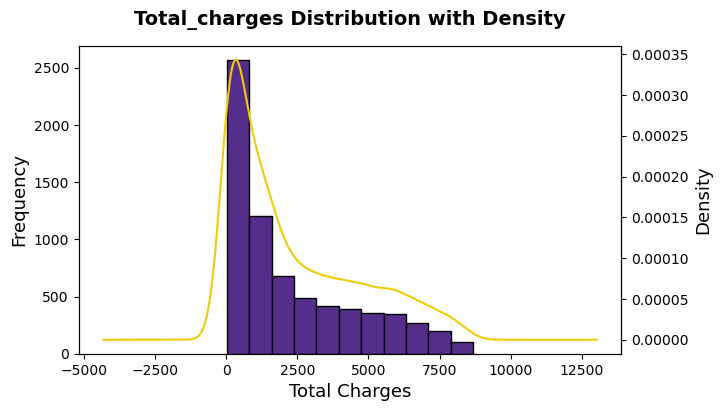

In [108]:
Hist2 = df['Total_charges'].plot(kind = 'hist' , bins = 11 , edgecolor = 'black' , color = '#552E8C' , figsize=(7, 4))
df['Total_charges'].plot(kind = 'kde' , color='#F2CB07' , secondary_y = True , ax = Hist2 )
plt.title('Total_charges Distribution with Density', fontsize=14, fontweight='bold', pad=15)
Hist2.set_xlabel('Total Charges', fontsize=13)
Hist2.set_ylabel('Frequency', fontsize=13)
plt.ylabel('Density', fontsize=13)

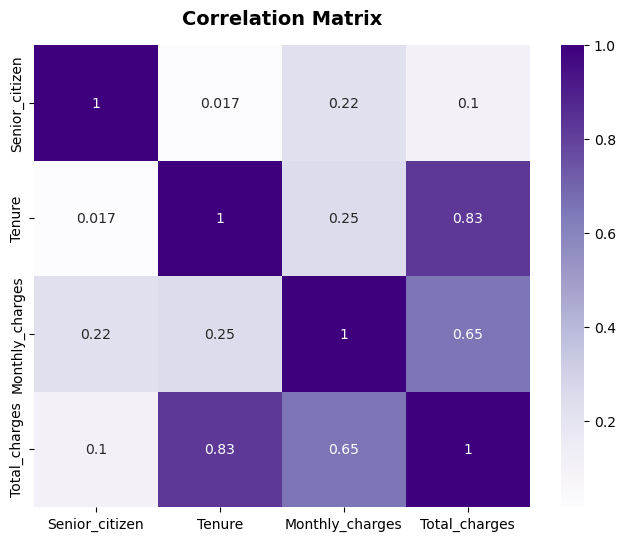

In [109]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Purples')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.show()

In [133]:
df

,Customer_ID,Gender,Senior_citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_lines,Internet_service,Online_security,Online_backup,Device_protection,Tech_support,Contract,Paperless_billing,Payment_method,Monthly_charges,Total_charges,Churn,Lines_count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Internet Only
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.50,No,Single_line
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Single_line
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No,Internet Only
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Single_line
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,2 or more lines
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,One year,Yes,Credit card (automatic),103.20,7362.90,No,2 or more lines
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Internet Only
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,2 or more lines


### Ranking
#### Top Contract way => Month-to-month
#### Top Payment_method => Electronic check
#### Top Internet Services => Fiber optic
#### Top Lines_count => Single_line
#### The most gender => Male

### Churn Drivers & Insights
#### Contract Type: Month-to-month contracts are the leading driver of customer churn.
#### Payment Methods: Customers using Electronic Check exhibit the highest churn rate compared to other payment options.
#### Internet Services: Fiber optic subscribers experience significantly higher churn volumes than DSL users.
#### Line Configuration: Customers with multiple lines (2 or more) are more likely to cancel their service than single-line users.
#### Demographics: Female customers show a slightly higher churn tendency compared to males.
#### Technical Support: A significant segment of retained customers (1,734 subscribers) utilizes Technical Support, highlighting its strong impact on customer loyalty.


In [159]:
df.to_csv(r"C:\Users\DELL\Downloads\Telecom_data.csv" , index= False )